Rozkład $\kappa(S)$, gdzie $S$ jest losowana z rozkładu standardowego normalnego, a więc macierzy przejścia w naszym datasecie `random` oraz `perturbed`, jest jak niżej. Przy okazji zgadza się całkiem nieźle z wynikiem teoretycznym Edelmana (https://math.mit.edu/~edelman/publications/eigenvalues_and_condition_numbers.pdf, Theorem 7.1.).

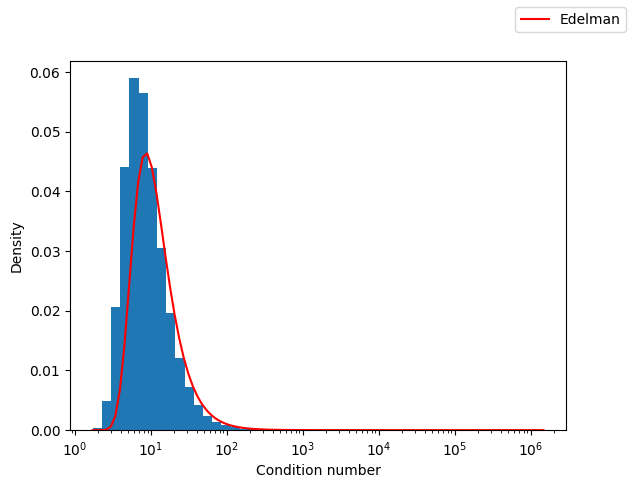

In [ ]:

matrices = [generate_S("random", 5) for _ in range(100000)]
conds = [np.linalg.cond(S) for S in matrices]
bins = np.logspace(np.log10(min(conds)), np.log10(max(conds)), 50)

x = np.pow(10, np.linspace(np.log10(min(conds)/5), np.log10(max(conds)/5), 100))
fig, ax1 = plt.subplots()

# First plot — histogram
ax1.hist(conds, bins=bins, cumulative=False, density=True)
ax1.set_xscale('log')
ax1.set_ylabel('Density')
ax1.set_xlabel('Condition number')

# Second plot — function on the same x axis
y = (2 * x + 4) / np.pow(x, 3) * np.exp(-2/x - 2/x**2)
ax1.plot(x * 5, y / 5, color='red', label='Edelman')
# Optional: legend
fig.legend(loc='upper right')


plt.show()


Postanowiłem stworzyć dodatkowe datasety testowe, gdzie mamy macierze $S^{-1}JS$, takie że $\kappa(S)$ jest konkretne (do generowania używałem SVD). I dla różnych wartości $\kappa(S)$ przetestowałem wartość accuracy.

In [ ]:
def random_matrix_with_condition(m, n=None, cond_number=10.0):
    """
    Generate an m x n random matrix with approximate condition = cond_number,
    using singular values drawn uniformly between 1/sqrt(cond) and sqrt(cond).
    """
    if n is None:
        n = m
        
    # random orthogonal factors from normal distribution
    U, _ = np.linalg.qr(np.random.randn(m, m))
    V, _ = np.linalg.qr(np.random.randn(n, n))

    min_dim = min(m, n)

    # limits for uniform singular values
    s_min = 1.0 / np.sqrt(cond_number)
    s_max = np.sqrt(cond_number)

    # draw singular values uniform in [s_min, s_max]
    s = np.concatenate([np.array([s_min, s_max]), np.random.uniform(low=s_min, high=s_max, size=min_dim-2)])

    # build Sigma
    Sigma = np.zeros((m, n))
    Sigma[:min_dim, :min_dim] = np.diag(s)

    return U @ Sigma @ V.T

def generate_matrix(d, block_size, mode, eps=None, lam=1, value_range=None, schur=False, cond=100):
    indexes = np.random.choice(d-1, size=block_size, replace=False)

    super_diag = np.zeros(d-1)
    for index in indexes:
        super_diag[index] = 1
    J = lam * np.eye(d) + np.diag(super_diag, k=1)
    if eps is not None:
        J += eps * np.random.randn(d, d)
    if value_range is None:
        match mode:
            case "random" | "upper" | "ortho" | "lower":
                value_range = 1
            case "int":
                value_range = 100
            case _:
                raise RuntimeError(f"Mode {mode} is not supported")

    S = random_matrix_with_condition(d, cond_number=cond)
    X = S @ J @ np.linalg.inv(S)
    if schur:
        return scipy.linalg.schur(X)[0]
    else:
        return X

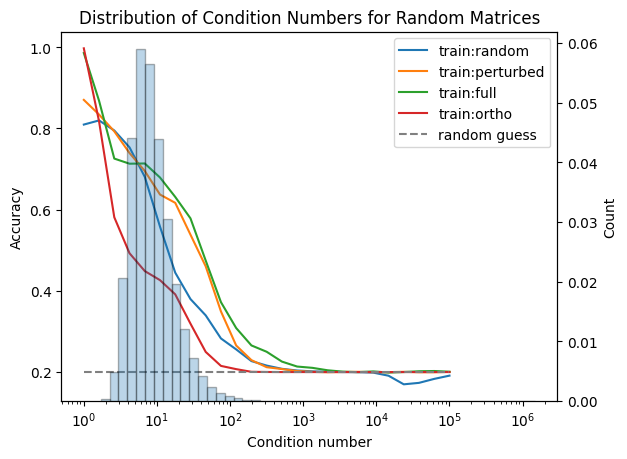

Nie jest zaskoczeniem, że im większe staje się $\kappa(S)$, tym gorzej sobie model radzi. Tego się spodziewamy po naszym modelu - żeby przewidywał, czy w otoczeniu macierzy $A$ istnieje taka, która ma określony blok Jordana, ale o dobrze uwarunkowanej macierzy przejścia. Zacząłem się jednak zastanawiać, czy spadek accuracy nie jest powiązany z niedoreprezentowaniem macierzy o wysokim $\kappa$. Podobnie niższe accuracy modelu wytrenowanego na losowych macierzach na zbiorze z macierzami przejścia ortogonalnymi, może być spowodowane tym, że w losowym datasecie takich prawie nie ma. Dorzucenie ich w datasecie full już ten problem naprawia. 

Myślałem, czy by nie spróbować rozsądniej podobierać macierze $S$ względem $\kappa(S)$. Np. uzyskać $\kappa(S) \sim Unif[0, 1000]$ i zobaczyć,czy taka krzywa accuracy będzie przypominała gęstość. 